<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week6_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama :** Hanif Faishal Hilmi

**Kelas :** TI-3F

**NIM :** 2341720116

# Praktikum Filter Spasial Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection

## D. PRAKTIKUM FILTER

### Membuat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa menggunakan library atau metode konvolusi dari OpenCV.  

1. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan

In [1]:
from google.colab import drive
drive.mount('/content/MyDrive')

Drive already mounted at /content/MyDrive; to attempt to forcibly remount, call drive.mount("/content/MyDrive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

2. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi. Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

In [3]:
import numpy as np

# image: Matriks 2D yang merepresentasikan citra input.
# kernel: Matriks 2D (biasanya lebih kecil dari citra) yang berfungsi sebagai filter.
# stride: Jumlah piksel pergeseran kernel pada setiap langkah.
# padding: Jumlah lapisan piksel bernilai nol yang ditambahkan di sekeliling citra.
def convolution2d(image, kernel, stride, padding):
  # 1. Menambahkan 'padding' (bingkai nol) di sekeliling citra.
  if padding > 0:
    image_padded = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
  else:
    image_padded = image

  # 2. Mendapatkan dimensi dari citra yang sudah diberi padding dan dimensi kernel.
  (image_height, image_width) = image_padded.shape
  (kernel_height, kernel_width) = kernel.shape

  # 3. Menghitung dimensi matriks output berdasarkan rumus konvolusi.
  output_height = int((image_height - kernel_height) / stride) + 1
  output_width = int((image_width - kernel_width) / stride) + 1

  # 4. Membuat matriks output baru yang diisi dengan nilai nol.
  output = np.zeros((output_height, output_width))

  # 5. Lakukan perulangan untuk menggeser kernel ke seluruh bagian citra.
  for y in range(0, output_height):
    for x in range(0, output_width):
      # Tentukan posisi 'jendela' atau potongan pada citra input.
      start_y = y * stride
      end_y = start_y + kernel_height
      start_x = x * stride
      end_x = start_x + kernel_width

      # Ambil potongan (slice) dari citra sesuai posisi jendela.
      image_slice = image_padded[start_y:end_y, start_x:end_x]

      # 6. Hitung nilai untuk satu piksel output:
      #    - Lakukan perkalian elemen-demi-elemen antara potongan citra dan kernel.
      #    - Jumlahkan semua hasil perkalian tersebut.
      #    Komentar sebelumnya kurang tepat, ini adalah inti perhitungan, bukan 'konvolusi pada potongan'.
      output[y, x] = np.sum(image_slice * kernel)

  return output

* Load image yang akan diproses

In [4]:
img = cv.imread('/content/MyDrive/MyDrive/PCVK25_3F_15/image/Pertemuan6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

* Tentukan kernel yang akan digunakan

In [5]:
kernel_sharpen = np.array([[0, -1, -0],
                           [-1, 9, -1],
                           [0, -1, 0]])

* Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

In [6]:
convolution2d(img_gray,kernel_sharpen,1,2)

array([[   0., -145.,  -56., ..., -153., -177.,    0.],
       [-145., 1133.,  209., ...,  938., 1315., -177.],
       [-116.,  721.,  583., ...,  845.,  718., -125.],
       ...,
       [-156., 1111.,  826., ...,  479.,  459.,  -69.],
       [ -11.,  -68.,  -66., ...,  -55.,  -37.,   -4.],
       [   0.,  -11.,  -11., ...,   -4.,   -4.,    0.]])

3. Membuat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter lainnya


In [7]:
# operasi sharpen
sharpen_kernel = np.array([[0, -1, -0],
                           [-1, 5, -1],
                           [0, -1, 0]])
# operasi emboss
emboss_kernel = np.array([[-2, -1, -0],
                           [-1, 1, 1],
                           [0, 1, 2]])

# operasi Left Sobel Edge Detection
lsed_kernel = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

# operasi Canny Edge Detection
ced_kernel = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]])

# operasi 21 x 21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

In [8]:
# eksekusi semua kodenya
sharpen_img = convolution2d(img_gray, sharpen_kernel, 1, 2)
emboss_img = convolution2d(img_gray, emboss_kernel, 1, 2)
lsed_img = convolution2d(img_gray, lsed_kernel, 1, 2)
ced_img = convolution2d(img_gray, ced_kernel, 1, 2)
gauss_img = convolution2d(img_gray, gauss_kernel, 1, 2)

# buat semua hasil filter menjadi list
filters = {
    "Sharpen": sharpen_img,
    "Emboss": emboss_img,
    "Left Sobel Edge Detection": lsed_img,
    "Canny Edge Detection": ced_img,
    "Gaussian Blur": gauss_img
}

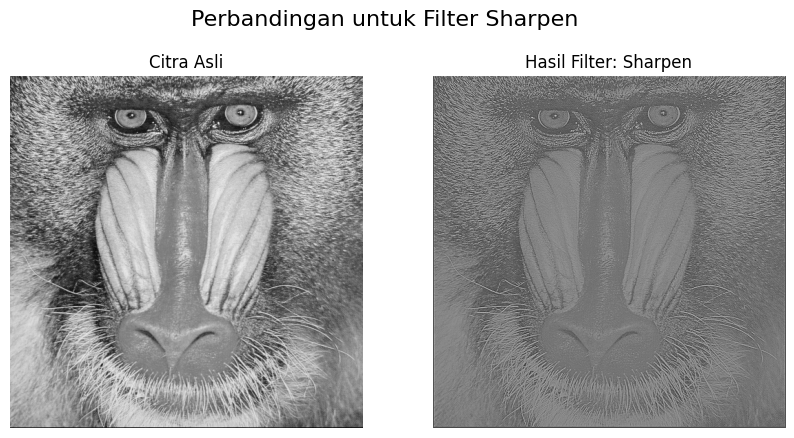

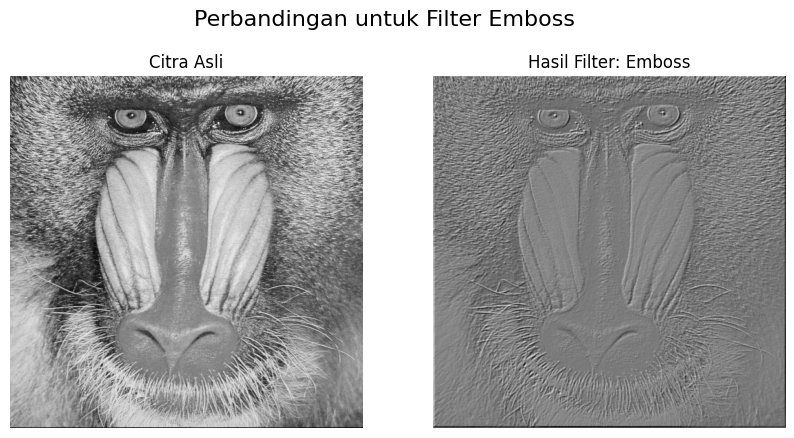

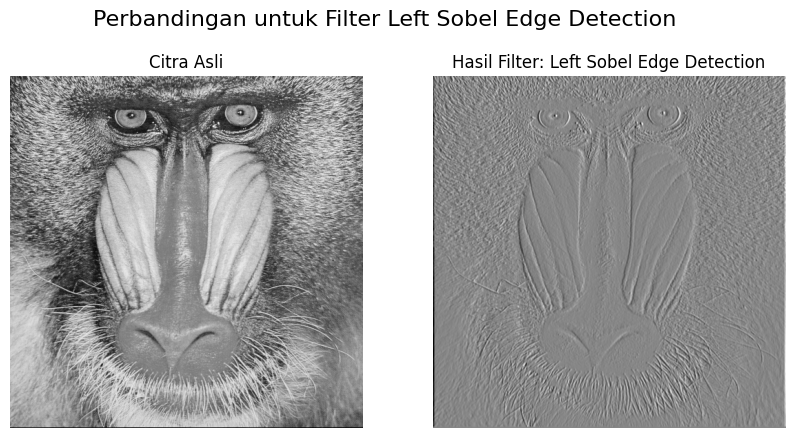

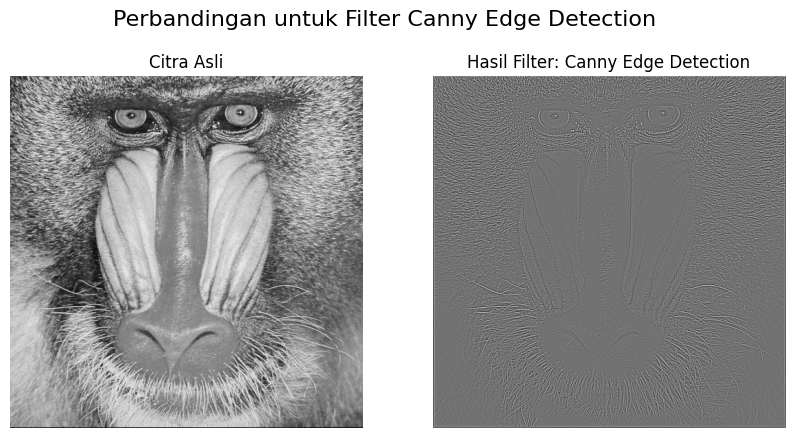

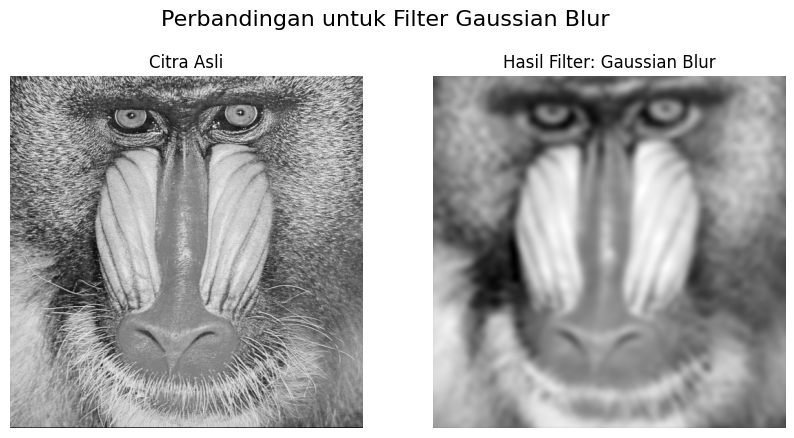

In [9]:
# Menampilkan plot hasil
# Membuat plot untuk setiap filter
for filter_name, filtered_image in filters.items():
    plt.figure(figsize=(10, 5))

    # Plot Citra Asli
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Citra Asli')
    plt.axis('off')

    # Plot Citra Hasil Filter
    plt.subplot(1, 2, 2)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'Hasil Filter: {filter_name}')
    plt.axis('off')

    plt.suptitle(f'Perbandingan untuk Filter {filter_name}', fontsize=16)
    plt.show()


## E. FILTER LIBRARY DAN FILTER MODERN

### Percobaan 1:

Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

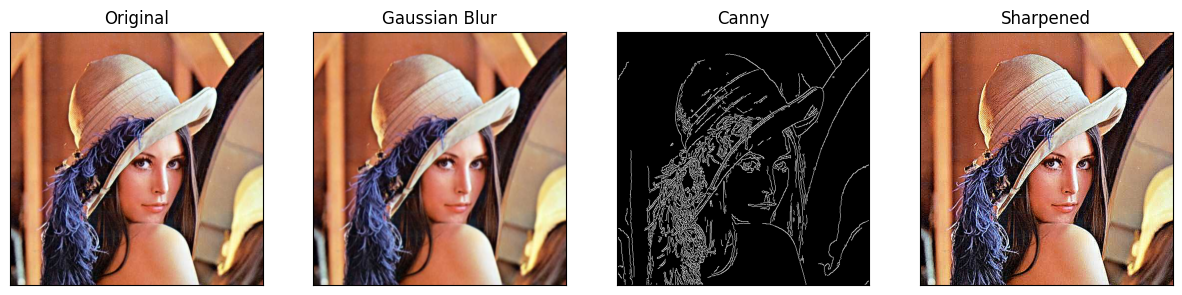

In [10]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) ==2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
  plt.show()

img = cv.imread('/content/MyDrive/MyDrive/PCVK25_3F_15/image/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1, 0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, edges, sharpened], ['Original', 'Gaussian Blur', 'Canny', 'Sharpened'])

### Percobaan 2

Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan digunakan adalah Bilateral Filtering dan Guided Filter. **Bilateral filtering** adalah sebuah metode penyaringan non-linear yang banyak digunakan untuk menghaluskan citra sekaligus tetap mempertahankan ketajaman tepi. Berbeda dengan Gaussian blur biasa yang hanya memperhitungkan jarak spasial antar piksel, bilateral filter juga mempertimbangkan perbedaan intensitas warna. Dengan
cara ini, piksel-piksel yang letaknya dekat dan memiliki warna mirip dengan pusat jendela akan mendapat bobot lebih besar dalam perhitungan, sedangkan piksel dengan perbedaan warna kontras (misalnya di sisi tepi) akan tereduksi pengaruhnya. Akibatnya, citra menjadi lebih halus pada area datar, namun garis batas dan detail penting tetap terjaga. Meskipun menghasilkan kualitas yang baik, bilateral filter tergolong lambat karena perhitungan bobot yang cukup kompleks. Dalam praktiknya, filter ini banyak dipakai untuk keperluan seperti perbaikan kualitas foto, pengurangan noise, maupun sebagai dasar dari efek beauty filter untuk melembutkan tekstur kulit tanpa mengaburkan kontur wajah.

**Guided filtering** merupakan teknik yang lebih modern dan efisien. Filter ini didasarkan pada asumsi bahwa, dalam sebuah jendela lokal, hasil penyaringan dapat direpresentasikan sebagai fungsi linear
dari citra pemandu (guide image). Artinya, setiap piksel keluaran dihitung dengan mempertimbangkan hubungan linier antara nilai piksel di citra masukan dengan nilai piksel pada citra pemandu. Jika citra
masukan dan citra pemandu sama, guided filter akan berperan mirip bilateral filter namun dengan perhitungan yang jauh lebih cepat dan hasil yang lebih halus. Keunggulan lainnya, guided filter bisa menggunakan citra yang berbeda sebagai pemandu sehingga mampu mengarahkan proses filtering sesuai kebutuhan. Berkat sifat ini, guided filter sering dipakai dalam berbagai aplikasi lanjutan seperti HDR tone mapping, peningkatan detail, image matting, feathering, serta pemurnian depth map pada
sistem stereo vision. Secara umum, guided filter menawarkan keseimbangan antara preservasi tepi yang baik, kualitas visual yang halus, dan efisiensi komputasi, sehingga dianggap sebagai penyempurnaan dari pendekatan bilateral filtering.

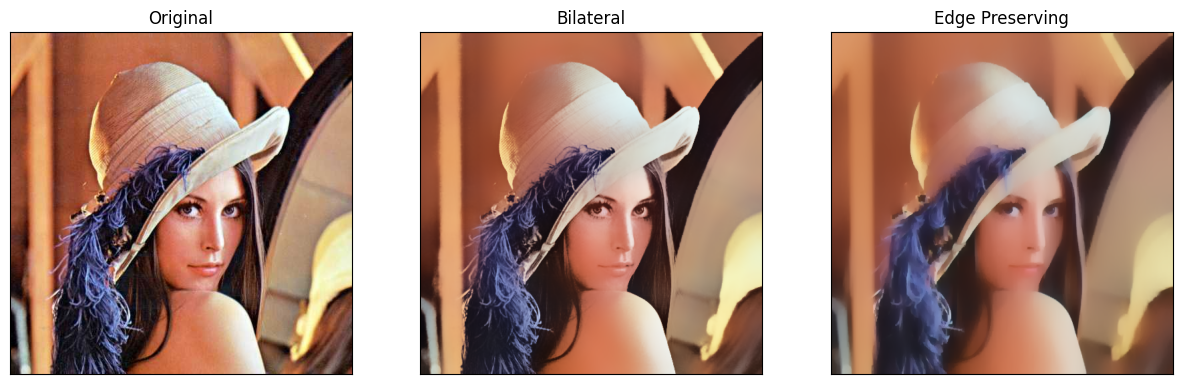

In [11]:
# Filter modern dari openCV

# Bilateral Filter
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Original', 'Bilateral', 'Edge Preserving'])

### Percobaan 3

Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil keluaran tersebut.

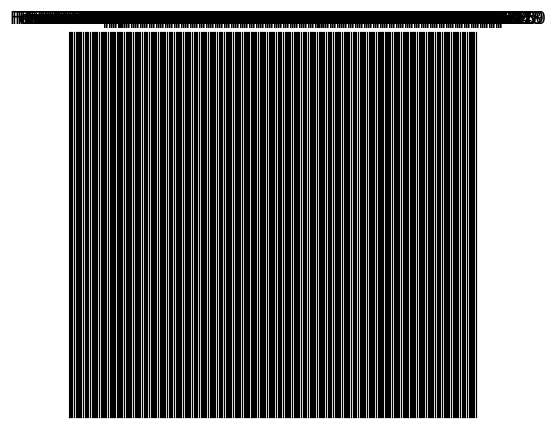

In [13]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.convl = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    return self.convl(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range (features.shape[1])]
show_side_by_side(feature_maps, [f'Feature Map {i+1}' for i in range(len(feature_maps))])

Dari hasil proses filtering dari CNN, bentuk dari garis-garis ini adalah proses bagaimana filtering bekerja.

### Percobaan 5

Percobaan 5 akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter tradisional.

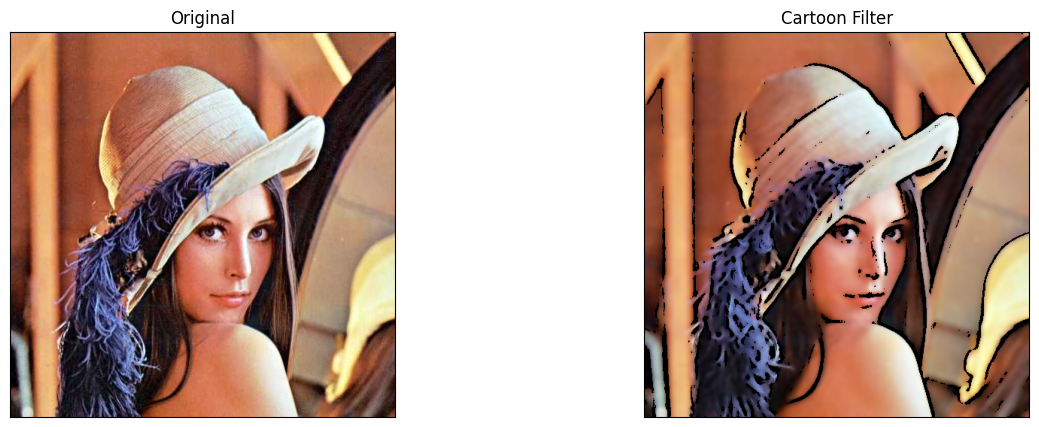

In [15]:
# Step 1: Deteksi Tepi (Membuat Garis Tinta Hitam)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Penghalusan Warna (Efek Lukisan)
# PERBAIKAN: Mengganti 'sigmacolor' menjadi 'sigmaColor'
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan Garis Tepi dan Warna Halus
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan hasil perbandingan
show_side_by_side([img, cartoon], ['Original', 'Cartoon Filter'])

### Percobaan 6:

Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.

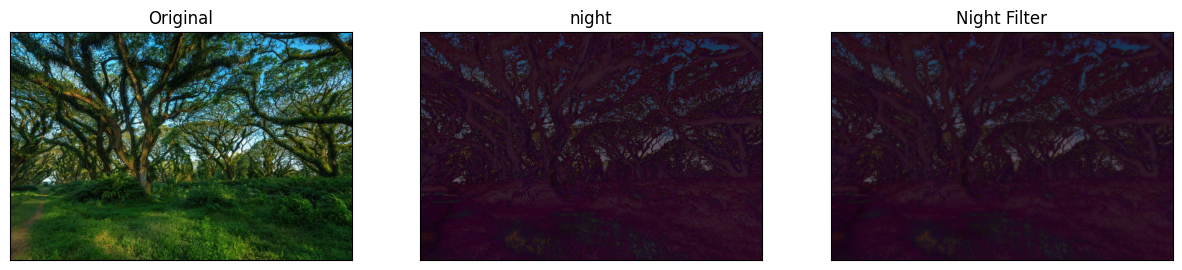

In [17]:
# Night Filter
img = cv.imread('/content/MyDrive/MyDrive/PCVK25_3F_15/image/Pertemuan6/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50,0,100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 255
glow = cv.filter2D(night, -1, kernel)

# Kombinasika asli +glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ['Original', 'night' , 'Night Filter'])

### Percobaan 7
Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.

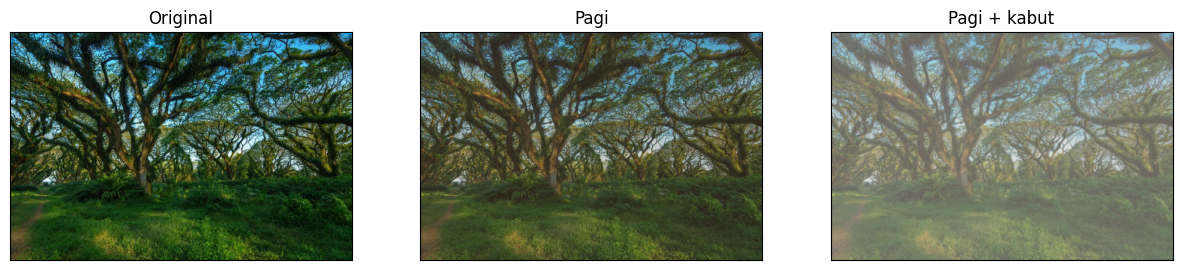

In [18]:
# Filter suasana pagi

# Step 1: Kurangi kontras & cerahkan
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40,70,120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haxe (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ['Original', 'Pagi' , 'Pagi + kabut'])